In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                                      f1_score, precision_score, recall_score,
                                      roc_curve, auc)
from xgboost import XGBClassifier

In [258]:

df = pd.read_csv('/content/drive/MyDrive/AIML_lab_sem4/Project/Health_Risk_Dataset.csv')



In [259]:
df.head()

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25,96,1,97,107,37.5,A,0,Medium
1,P0738,28,92,2,116,151,38.5,P,1,High
2,P0741,29,91,1,79,135,38.4,A,0,High
3,P0661,24,96,1,95,92,37.3,A,0,Medium
4,P0412,20,96,1,97,97,37.4,A,0,Low


In [260]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         1000 non-null   object 
 1   Respiratory_Rate   1000 non-null   int64  
 2   Oxygen_Saturation  1000 non-null   int64  
 3   O2_Scale           1000 non-null   int64  
 4   Systolic_BP        1000 non-null   int64  
 5   Heart_Rate         1000 non-null   int64  
 6   Temperature        1000 non-null   float64
 7   Consciousness      1000 non-null   object 
 8   On_Oxygen          1000 non-null   int64  
 9   Risk_Level         1000 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 78.3+ KB


In [261]:
df.isnull().sum()

,0
Patient_ID,0
Respiratory_Rate,0
Oxygen_Saturation,0
O2_Scale,0
Systolic_BP,0
Heart_Rate,0
Temperature,0
Consciousness,0
On_Oxygen,0
Risk_Level,0


In [262]:
df.describe()

,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,On_Oxygen
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,21.511000,92.59000,1.124000,106.160000,98.460000,37.921000,0.274000
std,5.287517,4.47302,0.329746,17.897562,19.694626,1.113696,0.446232
min,12.000000,74.00000,1.000000,50.000000,60.000000,35.600000,0.000000
25%,17.000000,90.00000,1.000000,94.000000,84.000000,37.100000,0.000000
50%,20.000000,94.00000,1.000000,109.000000,95.500000,37.800000,0.000000
75%,25.000000,96.00000,1.000000,119.000000,109.000000,38.600000,1.000000
max,40.000000,100.00000,2.000000,146.000000,163.000000,41.800000,1.000000


In [263]:
TARGET = 'Risk_Level'

print(f"Target column : '{TARGET}'")
print('\nClass Distribution (before encoding):')
print(df[TARGET].value_counts())
print(f'\nTotal classes : {df[TARGET].nunique()}')

Target column : 'Risk_Level'

Class Distribution (before encoding):
Risk_Level
Medium    306
High      279
Low       255
Normal    160
Name: count, dtype: int64

Total classes : 4


Generating EDA Plots...


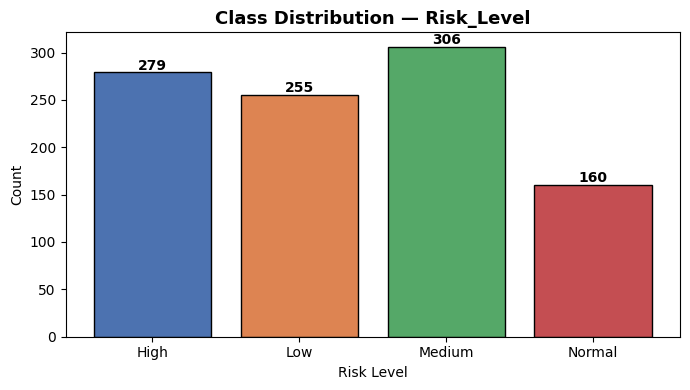

Saved: plot1_class_distribution.png


In [264]:
print('Generating EDA Plots...')

counts = df[TARGET].value_counts().sort_index()
colors_cls = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

plt.figure(figsize=(7, 4))
bars = plt.bar(counts.index.astype(str), counts.values,
               color=colors_cls[:len(counts)], edgecolor='black')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(counts.values) * 0.01,
             str(bar.get_height()), ha='center', fontweight='bold', fontsize=10)
plt.title(f'Class Distribution — {TARGET}', fontsize=13, fontweight='bold')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150)
plt.show()
print('Saved: plot1_class_distribution.png')

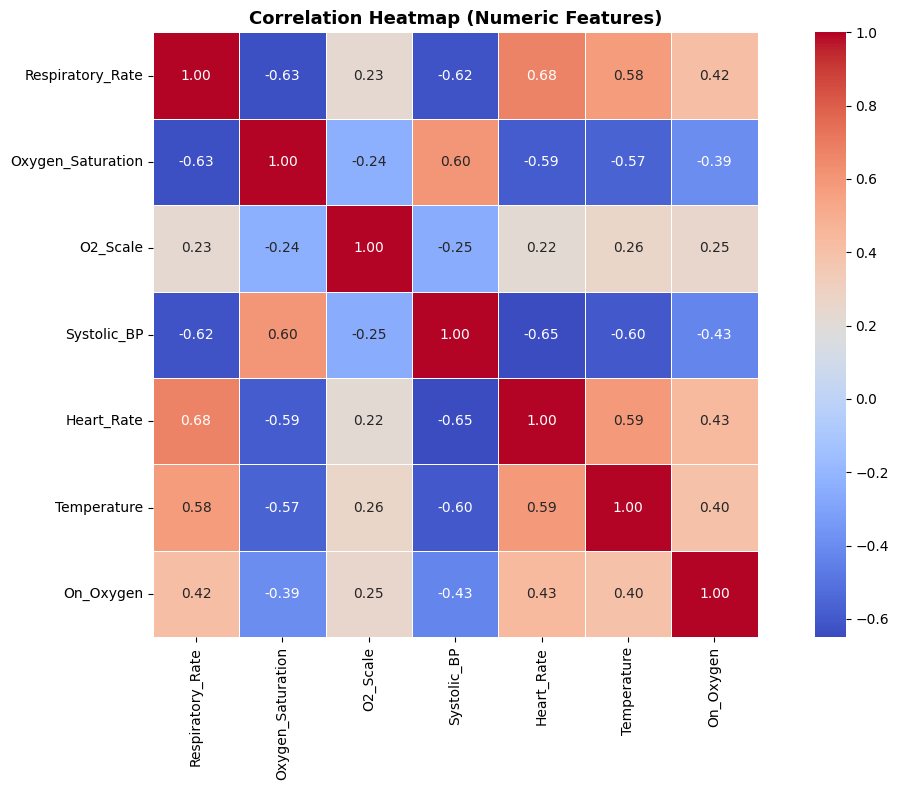

Saved: plot3_correlation_heatmap.png


In [265]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Heatmap (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_correlation_heatmap.png', dpi=150)
plt.show()
print('Saved: plot3_correlation_heatmap.png')

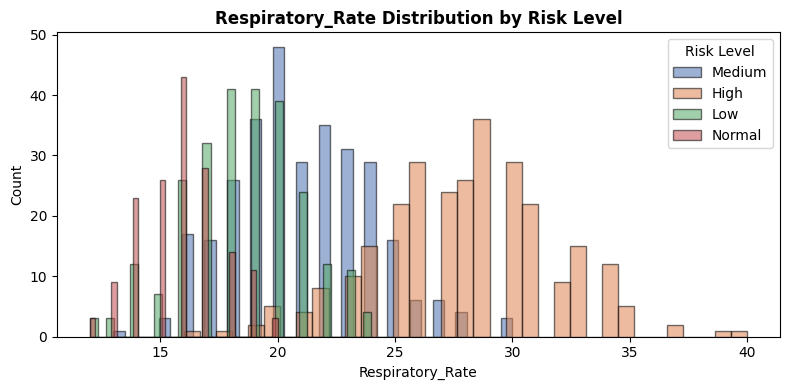

Saved: plot4_feature_by_class.png


In [266]:
KEY_FEATURE = numeric_df.columns[0]   # change to preferred column if desired

plt.figure(figsize=(8, 4))
for cls, clr in zip(df[TARGET].unique(), colors_cls):
    subset = df[df[TARGET] == cls][KEY_FEATURE].dropna()
    plt.hist(subset, bins=35, alpha=0.55, color=clr,
             label=str(cls), edgecolor='black')
plt.title(f'{KEY_FEATURE} Distribution by Risk Level', fontsize=12, fontweight='bold')
plt.xlabel(KEY_FEATURE)
plt.ylabel('Count')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.savefig('plot4_feature_by_class.png', dpi=150)
plt.show()
print('Saved: plot4_feature_by_class.png')

Preprocessing

In [267]:


df = df.drop(columns=['Patient_ID'], errors='ignore')


In [268]:
le_cons = LabelEncoder()
df['Consciousness'] = le_cons.fit_transform(df['Consciousness'])
print('Encoded: Consciousness')


Encoded: Consciousness


In [269]:

le_target = LabelEncoder()
df[TARGET]  = le_target.fit_transform(df[TARGET])

In [270]:
X = df.drop(columns=[TARGET])
y = df[TARGET]


In [271]:
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


In [272]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [273]:
m1 = LogisticRegression(penalty=None, multi_class='multinomial',
                        solver='lbfgs', max_iter=10000, random_state=RANDOM_STATE)
m1.fit(X_train_scaled, y_train)
p1 = m1.predict(X_test_scaled)

print('--- Model 1: Logistic Regression ---')
print(classification_report(y_test, p1, target_names=le_target.classes_))

--- Model 1: Logistic Regression ---
              precision    recall  f1-score   support

        High       1.00      0.95      0.97        56
         Low       0.91      0.98      0.94        51
      Medium       0.94      0.97      0.95        61
      Normal       1.00      0.91      0.95        32

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.96       200



In [274]:
print('Manually tuning L1 Logistic Regression...')
m2 = LogisticRegression(penalty='l1', solver='saga', multi_class='multinomial',
                        max_iter=5000, C=0.1, random_state=RANDOM_STATE)
m2.fit(X_train_scaled, y_train)
p2 = m2.predict(X_test_scaled)
print('L1 Logistic Regression (C=0.1) fitted.')

print('\n--- Model 2: Logistic Regression L1 ---')
print(classification_report(y_test, p2, target_names=le_target.classes_))

Manually tuning L1 Logistic Regression...
L1 Logistic Regression (C=0.1) fitted.

--- Model 2: Logistic Regression L1 ---
              precision    recall  f1-score   support

        High       1.00      0.96      0.98        56
         Low       0.92      0.88      0.90        51
      Medium       0.89      0.97      0.93        61
      Normal       0.97      0.94      0.95        32

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



In [275]:
print('Manually tuning L2 Logistic Regression...')
m3 = LogisticRegression(penalty='l2', solver='lbfgs', multi_class='multinomial',
                        max_iter=1000, C=0.01, random_state=RANDOM_STATE)
m3.fit(X_train_scaled, y_train)
p3 = m3.predict(X_test_scaled)
print('L2 Logistic Regression (C=0.01) fitted.')

print('\n--- Model 3: Logistic Regression L2 ---')
print(classification_report(y_test, p3, target_names=le_target.classes_))

Manually tuning L2 Logistic Regression...
L2 Logistic Regression (C=0.01) fitted.

--- Model 3: Logistic Regression L2 ---
              precision    recall  f1-score   support

        High       1.00      0.95      0.97        56
         Low       0.85      0.86      0.85        51
      Medium       0.86      0.97      0.91        61
      Normal       1.00      0.81      0.90        32

    accuracy                           0.91       200
   macro avg       0.93      0.90      0.91       200
weighted avg       0.92      0.91      0.91       200



In [276]:
m4 = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
m4.fit(X_train_scaled, y_train)
p4 = m4.predict(X_test_scaled)

print('--- Model 4: Decision Tree ---')
print(classification_report(y_test, p4, target_names=le_target.classes_))

--- Model 4: Decision Tree ---
              precision    recall  f1-score   support

        High       0.98      0.93      0.95        56
         Low       0.81      0.86      0.84        51
      Medium       0.83      0.87      0.85        61
      Normal       1.00      0.91      0.95        32

    accuracy                           0.89       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.90      0.89      0.89       200



In [277]:
m5 = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5),
                       n_estimators=50, random_state=RANDOM_STATE)
m5.fit(X_train_scaled, y_train)
p5 = m5.predict(X_test_scaled)

print('--- Model 5: Bagging Classifier ---')
print(classification_report(y_test, p5, target_names=le_target.classes_))


--- Model 5: Bagging Classifier ---
              precision    recall  f1-score   support

        High       0.98      0.95      0.96        56
         Low       0.84      0.84      0.84        51
      Medium       0.83      0.90      0.87        61
      Normal       1.00      0.91      0.95        32

    accuracy                           0.90       200
   macro avg       0.91      0.90      0.91       200
weighted avg       0.90      0.90      0.90       200



In [278]:

m_xgb = XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='mlogloss')
m_xgb.fit(X_train_scaled, y_train)
p_xgb = m_xgb.predict(X_test_scaled)

print('\n--- Model 6: XGBoost Classifier ---')
print(classification_report(y_test, p_xgb, target_names=le_target.classes_))


--- Model 6: XGBoost Classifier ---
              precision    recall  f1-score   support

        High       0.96      0.96      0.96        56
         Low       0.96      0.94      0.95        51
      Medium       0.92      0.95      0.94        61
      Normal       1.00      0.97      0.98        32

    accuracy                           0.95       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.95      0.96       200



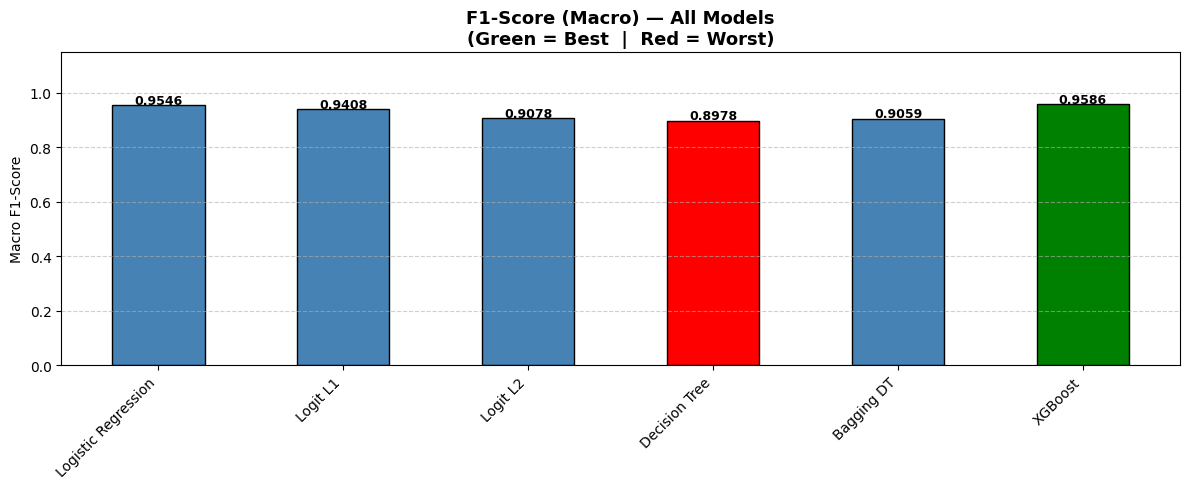

Saved: plot5_f1_bar.png


In [280]:
bar_colors_f1 = [
    'green'     if v == max(f1_macro_scores) else
    'red'       if v == min(f1_macro_scores) else
    'steelblue'
    for v in f1_macro_scores
]

plt.figure(figsize=(12, 5))
bars = plt.bar(model_names, f1_macro_scores,
               color=bar_colors_f1, edgecolor='black', width=0.5)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.4f}',
             ha='center', fontsize=9, fontweight='bold')
plt.title('F1-Score (Macro) — All Models\n(Green = Best  |  Red = Worst)',
          fontsize=13, fontweight='bold')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.15)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('plot5_f1_bar.png', dpi=150)
plt.show()
print('Saved: plot5_f1_bar.png')

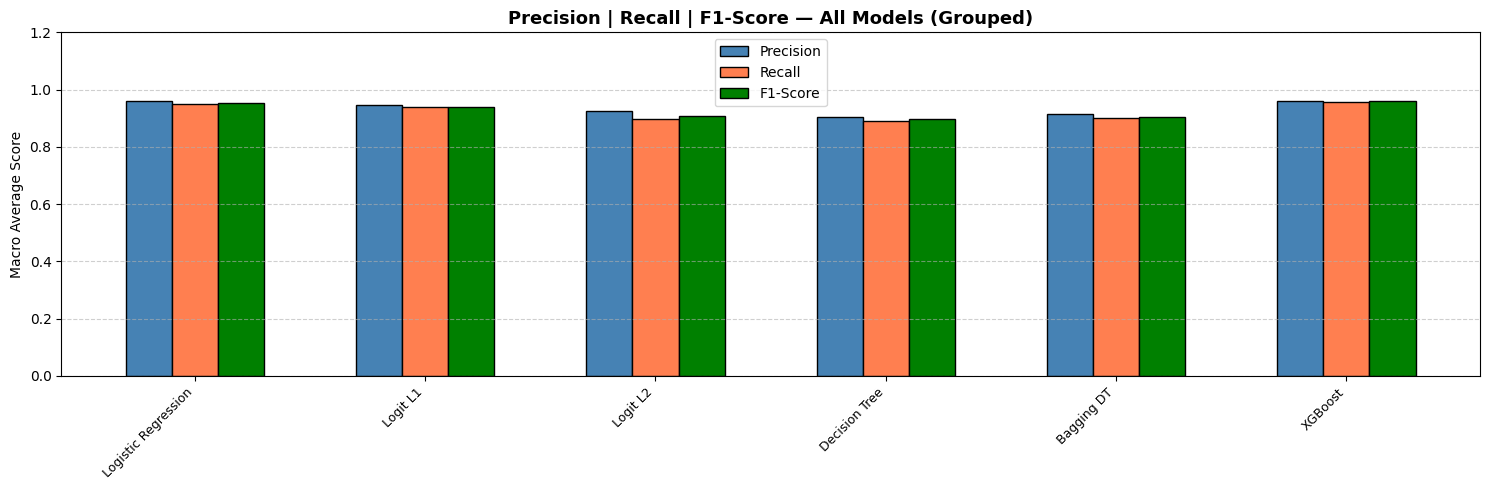

Saved: plot6_grouped_bar.png


In [281]:
x = np.arange(len(model_names))
w = 0.2

plt.figure(figsize=(15, 5))
plt.bar(x - w, precision_macro_scores, w,
        label='Precision', color='steelblue', edgecolor='black')
plt.bar(x,     recall_macro_scores,    w,
        label='Recall',    color='coral',     edgecolor='black')
plt.bar(x + w, f1_macro_scores,        w,
        label='F1-Score',  color='green',     edgecolor='black')

plt.xticks(x, model_names, rotation=45, ha='right', fontsize=9)
plt.ylabel('Macro Average Score')
plt.ylim(0, 1.2)
plt.title('Precision | Recall | F1-Score — All Models (Grouped)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('plot6_grouped_bar.png', dpi=150)
plt.show()
print('Saved: plot6_grouped_bar.png')

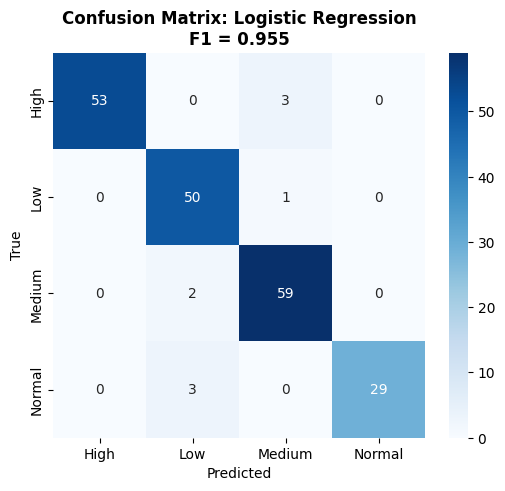

In [282]:
# Model 1: Baseline
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, p1), annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix: {model_names[0]}\nF1 = {f1_macro_scores[0]:.3f}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

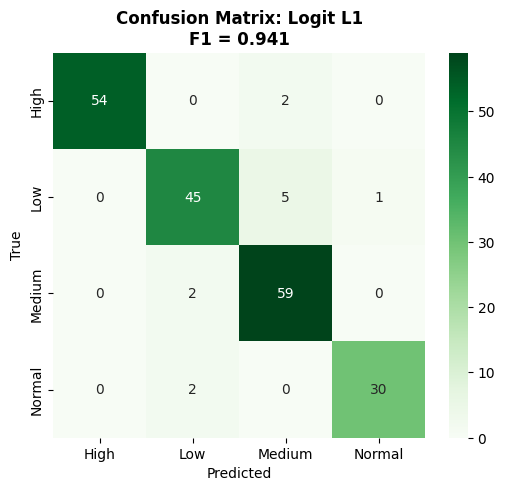

In [283]:
# Model 2: Lasso (L1)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, p2), annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix: {model_names[1]}\nF1 = {f1_macro_scores[1]:.3f}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

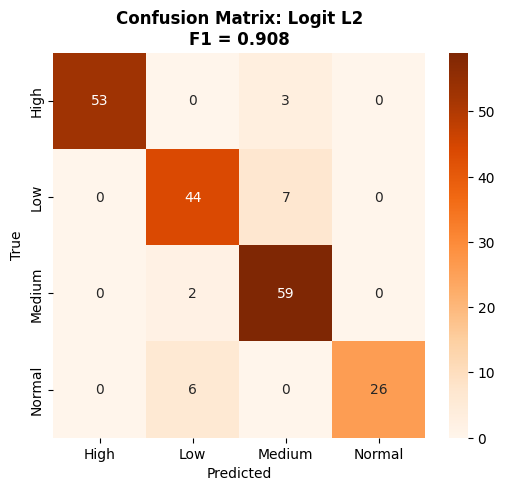

In [284]:
# Model 3: Ridge (L2)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, p3), annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix: {model_names[2]}\nF1 = {f1_macro_scores[2]:.3f}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

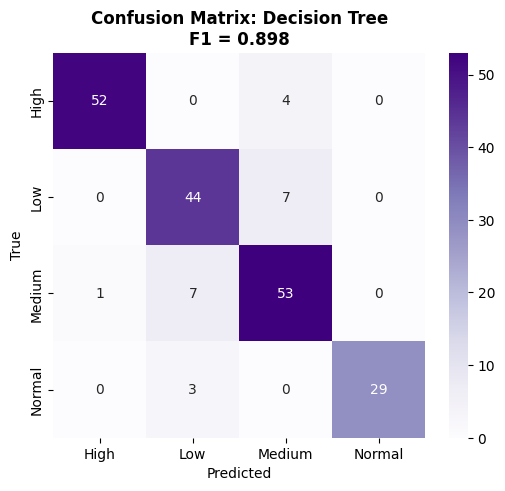

In [285]:
# Model 4: Decision Tree
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, p4), annot=True, fmt='d', cmap='Purples',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix: {model_names[3]}\nF1 = {f1_macro_scores[3]:.3f}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

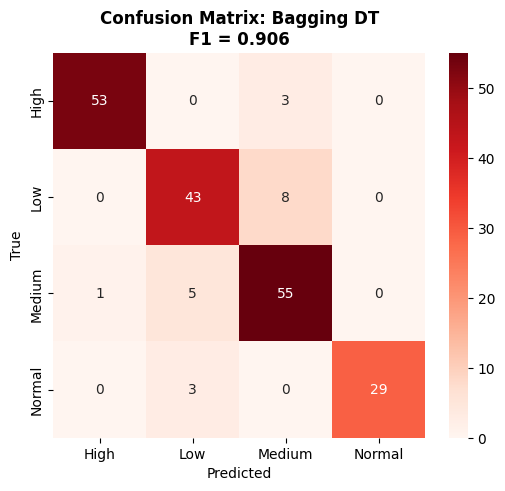

In [286]:
# Model 5: Random Forest
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, p5), annot=True, fmt='d', cmap='Reds',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix: {model_names[4]}\nF1 = {f1_macro_scores[4]:.3f}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

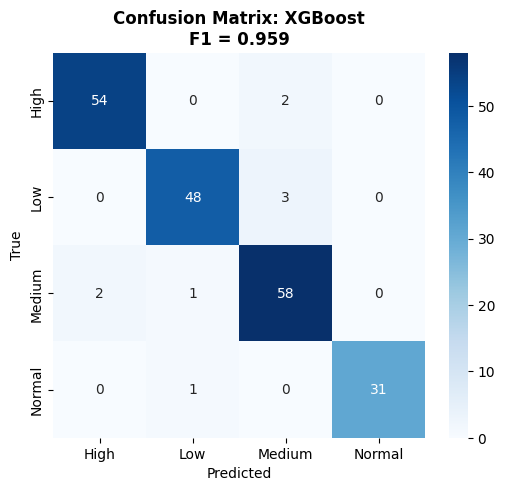

In [287]:
# Model 6: XGBoost
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, p_xgb), annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix: {model_names[5]}\nF1 = {f1_macro_scores[5]:.3f}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

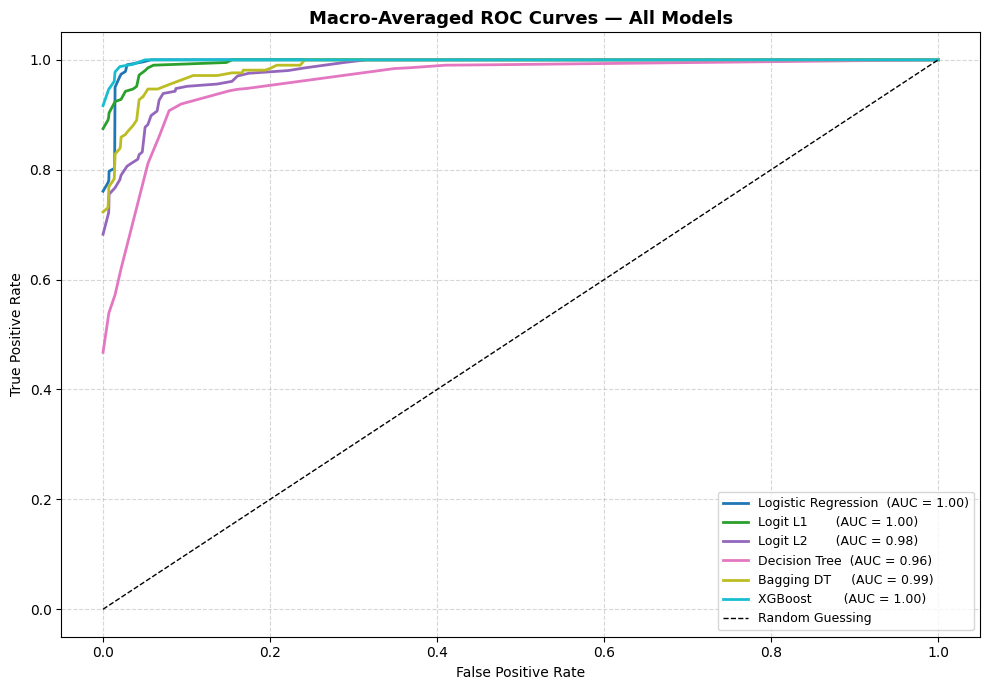

Saved: plot8_roc_curves.png


In [288]:
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
n_classes  = y_test_bin.shape[1]

models_roc = [
    ('Logistic Regression', m1),
    ('Logit L1',      m2),
    ('Logit L2',      m3),
    ('Decision Tree', m4),
    ('Bagging DT',    m5),
    ('XGBoost',       m_xgb)
]

roc_colors = plt.cm.tab10(np.linspace(0, 1, len(models_roc)))
auc_scores_list = []

plt.figure(figsize=(10, 7))

y_score_m1 = m1.predict_proba(X_test_scaled)
fpr_m1, tpr_m1, roc_auc_m1 = {}, {}, {}
for i in range(n_classes):
    fpr_m1[i], tpr_m1[i], _ = roc_curve(y_test_bin[:, i], y_score_m1[:, i])
    roc_auc_m1[i] = auc(fpr_m1[i], tpr_m1[i])
all_fpr_m1  = np.unique(np.concatenate([fpr_m1[i] for i in range(n_classes)]))
mean_tpr_m1 = np.zeros_like(all_fpr_m1)
for i in range(n_classes):
    mean_tpr_m1 += np.interp(all_fpr_m1, fpr_m1[i], tpr_m1[i])
mean_tpr_m1 /= n_classes
macro_auc_m1 = auc(all_fpr_m1, mean_tpr_m1)
plt.plot(all_fpr_m1, mean_tpr_m1, color=roc_colors[0], linewidth=2,
         label=f'Logistic Regression  (AUC = {macro_auc_m1:.2f})')
auc_scores_list.append({'Model': 'Logistic Regression', 'AUC': macro_auc_m1})

# --- Logit L1 ---
y_score_m2 = m2.predict_proba(X_test_scaled)
fpr_m2, tpr_m2, roc_auc_m2 = {}, {}, {}
for i in range(n_classes):
    fpr_m2[i], tpr_m2[i], _ = roc_curve(y_test_bin[:, i], y_score_m2[:, i])
    roc_auc_m2[i] = auc(fpr_m2[i], tpr_m2[i])
all_fpr_m2  = np.unique(np.concatenate([fpr_m2[i] for i in range(n_classes)]))
mean_tpr_m2 = np.zeros_like(all_fpr_m2)
for i in range(n_classes):
    mean_tpr_m2 += np.interp(all_fpr_m2, fpr_m2[i], tpr_m2[i])
mean_tpr_m2 /= n_classes
macro_auc_m2 = auc(all_fpr_m2, mean_tpr_m2)
plt.plot(all_fpr_m2, mean_tpr_m2, color=roc_colors[1], linewidth=2,
         label=f'Logit L1       (AUC = {macro_auc_m2:.2f})')
auc_scores_list.append({'Model': 'Logit L1', 'AUC': macro_auc_m2})

# --- Logit L2 ---
y_score_m3 = m3.predict_proba(X_test_scaled)
fpr_m3, tpr_m3, roc_auc_m3 = {}, {}, {}
for i in range(n_classes):
    fpr_m3[i], tpr_m3[i], _ = roc_curve(y_test_bin[:, i], y_score_m3[:, i])
    roc_auc_m3[i] = auc(fpr_m3[i], tpr_m3[i])
all_fpr_m3  = np.unique(np.concatenate([fpr_m3[i] for i in range(n_classes)]))
mean_tpr_m3 = np.zeros_like(all_fpr_m3)
for i in range(n_classes):
    mean_tpr_m3 += np.interp(all_fpr_m3, fpr_m3[i], tpr_m3[i])
mean_tpr_m3 /= n_classes
macro_auc_m3 = auc(all_fpr_m3, mean_tpr_m3)
plt.plot(all_fpr_m3, mean_tpr_m3, color=roc_colors[2], linewidth=2,
         label=f'Logit L2       (AUC = {macro_auc_m3:.2f})')
auc_scores_list.append({'Model': 'Logit L2', 'AUC': macro_auc_m3})

# --- Decision Tree ---
y_score_m4 = m4.predict_proba(X_test_scaled)
fpr_m4, tpr_m4, roc_auc_m4 = {}, {}, {}
for i in range(n_classes):
    fpr_m4[i], tpr_m4[i], _ = roc_curve(y_test_bin[:, i], y_score_m4[:, i])
    roc_auc_m4[i] = auc(fpr_m4[i], tpr_m4[i])
all_fpr_m4  = np.unique(np.concatenate([fpr_m4[i] for i in range(n_classes)]))
mean_tpr_m4 = np.zeros_like(all_fpr_m4)
for i in range(n_classes):
    mean_tpr_m4 += np.interp(all_fpr_m4, fpr_m4[i], tpr_m4[i])
mean_tpr_m4 /= n_classes
macro_auc_m4 = auc(all_fpr_m4, mean_tpr_m4)
plt.plot(all_fpr_m4, mean_tpr_m4, color=roc_colors[3], linewidth=2,
         label=f'Decision Tree  (AUC = {macro_auc_m4:.2f})')
auc_scores_list.append({'Model': 'Decision Tree', 'AUC': macro_auc_m4})

# --- Bagging DT ---
y_score_m5 = m5.predict_proba(X_test_scaled)
fpr_m5, tpr_m5, roc_auc_m5 = {}, {}, {}
for i in range(n_classes):
    fpr_m5[i], tpr_m5[i], _ = roc_curve(y_test_bin[:, i], y_score_m5[:, i])
    roc_auc_m5[i] = auc(fpr_m5[i], tpr_m5[i])
all_fpr_m5  = np.unique(np.concatenate([fpr_m5[i] for i in range(n_classes)]))
mean_tpr_m5 = np.zeros_like(all_fpr_m5)
for i in range(n_classes):
    mean_tpr_m5 += np.interp(all_fpr_m5, fpr_m5[i], tpr_m5[i])
mean_tpr_m5 /= n_classes
macro_auc_m5 = auc(all_fpr_m5, mean_tpr_m5)
plt.plot(all_fpr_m5, mean_tpr_m5, color=roc_colors[4], linewidth=2,
         label=f'Bagging DT     (AUC = {macro_auc_m5:.2f})')
auc_scores_list.append({'Model': 'Bagging DT', 'AUC': macro_auc_m5})

# --- XGBoost ---
y_score_xgb = m_xgb.predict_proba(X_test_scaled) # Predictions for XGBoost
fpr_xgb, tpr_xgb, roc_auc_xgb = {}, {}, {}
for i in range(n_classes):
    fpr_xgb[i], tpr_xgb[i], _ = roc_curve(y_test_bin[:, i], y_score_xgb[:, i])
    roc_auc_xgb[i] = auc(fpr_xgb[i], tpr_xgb[i])
all_fpr_xgb  = np.unique(np.concatenate([fpr_xgb[i] for i in range(n_classes)]))
mean_tpr_xgb = np.zeros_like(all_fpr_xgb)
for i in range(n_classes):
    mean_tpr_xgb += np.interp(all_fpr_xgb, fpr_xgb[i], tpr_xgb[i])
mean_tpr_xgb /= n_classes
macro_auc_xgb = auc(all_fpr_xgb, mean_tpr_xgb)
plt.plot(all_fpr_xgb, mean_tpr_xgb, color=roc_colors[5], linewidth=2,
         label=f'XGBoost        (AUC = {macro_auc_xgb:.2f})')
auc_scores_list.append({'Model': 'XGBoost', 'AUC': macro_auc_xgb})


plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Averaged ROC Curves — All Models',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot8_roc_curves.png', dpi=150)
plt.show()
print('Saved: plot8_roc_curves.png')

In [289]:
auc_vals_dict = {
    'Logistic Regression': macro_auc_m1,
    'Logit L1'     : macro_auc_m2,
    'Logit L2'     : macro_auc_m3,
    'Decision Tree': macro_auc_m4,
    'Bagging DT'   : macro_auc_m5,
    'XGBoost'      : macro_auc_xgb # Added XGBoost AUC
}

summary_df = pd.DataFrame({
    'Model'    : model_names,
    'Precision': precision_macro_scores,
    'Recall'   : recall_macro_scores,
    'F1-Score' : f1_macro_scores,
    'AUC'      : [macro_auc_m1, macro_auc_m2, macro_auc_m3, macro_auc_m4, macro_auc_m5, macro_auc_xgb], # Added XGBoost AUC
    'Accuracy' : accuracy_scores
})

summary_df = summary_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
summary_df.index += 1

print('=' * 65)
print('   FINAL RESULTS — Ranked by Macro F1-Score')
print('=' * 65)
display(summary_df)

   FINAL RESULTS — Ranked by Macro F1-Score


,Model,Precision,Recall,F1-Score,AUC,Accuracy
1,XGBoost,0.961230,0.956258,0.958598,0.998877,0.955
2,Logistic Regression,0.961400,0.950071,0.954576,0.996385,0.955
3,Logit L1,0.945012,0.937838,0.940833,0.995876,0.940
4,Logit L2,0.925307,0.897222,0.907773,0.980754,0.910
5,Bagging DT,0.914488,0.899364,0.905934,0.987020,0.900
6,Decision Tree,0.906018,0.891605,0.897761,0.961525,0.890
